# Critérios de avaliação de classificadores

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Ler matriz de confusão, precisão, recall, F1 e importância de atributos.

**Pergunta-guia:** Quando acurácia pode esconder erros importantes?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

Acurácia: 0.889
Matriz de confusão (linhas=reais, colunas=previstas):
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]
setosa: precisão=1.00, recall=1.00, F1=1.00, suporte=15
versicolor: precisão=0.78, recall=0.93, F1=0.85, suporte=15
virginica: precisão=0.92, recall=0.73, F1=0.81, suporte=15


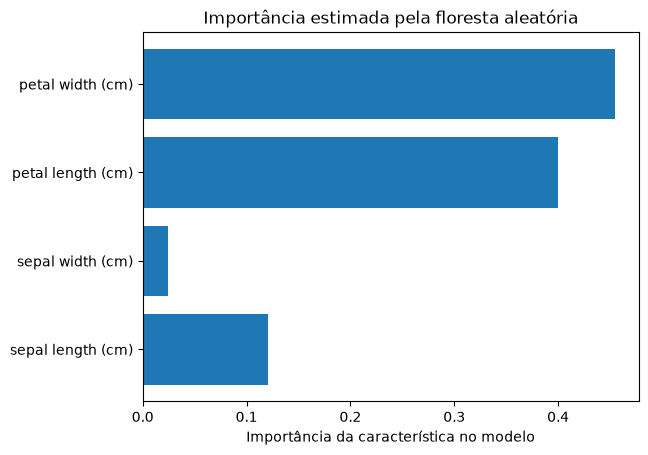

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, stratify=iris.target, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred = rf.predict(X_test)
precisao, recall, f1, suporte = precision_recall_fscore_support(
    y_test, y_pred, labels=[0, 1, 2], zero_division=0)
print('Acurácia:', round(accuracy_score(y_test, y_pred), 3))
print('Matriz de confusão (linhas=reais, colunas=previstas):')
print(confusion_matrix(y_test, y_pred))
for classe, p, r, f, n in zip(iris.target_names, precisao, recall, f1, suporte):
    print(f'{classe}: precisão={p:.2f}, recall={r:.2f}, F1={f:.2f}, suporte={n}')

# Importância auxilia a discutir o modelo, mas não mede qualidade nem causalidade.
plt.barh(iris.feature_names, rf.feature_importances_)
plt.xlabel('Importância da característica no modelo')
plt.title('Importância estimada pela floresta aleatória')
plt.show()

## Interpretação e limites

Importância de atributo não é uma medida de qualidade preditiva nem prova causalidade.

## Exercício

Crie um alvo desbalanceado e compare as métricas com a classe majoritária. Como extensão, inspecione `data/12.1 - dados_comentarios.csv` e defina uma avaliação de classificação de texto.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.